In [1]:
import numpy as np
import pandas as pd

# CSV files exported from Earth Engine (same folder as this notebook)
FILES = {
    'era5land': 'Sisal_ERA5Land_daily.csv',
    'era5':     'Sisal_ERA5_daily.csv',
    'hycom':    'Sisal_HYCOM_daily.csv',
}

# kind:    'linear'   ordinary variable (averaged)
#          'flux'     daily amount, e.g. mm/day (summed to monthly totals)
#          'circular' direction in degrees (averaged as a vector)
# monthly: optional override of the monthly aggregation ('mean', 'sum', 'max')
# Units are already converted in the Earth Engine export.
VARIABLES = {
    # ERA5-Land, two inland cells (choose CELL = 'c1' or 'c2')
    't2m_c':       dict(src='era5land', label='2 m air temperature (daily mean)', unit='°C',   kind='linear'),
    't2m_min_c':   dict(src='era5land', label='2 m air temperature (daily min)',  unit='°C',   kind='linear'),
    't2m_max_c':   dict(src='era5land', label='2 m air temperature (daily max)',  unit='°C',   kind='linear'),
    'skin_t_c':    dict(src='era5land', label='Skin temperature',                  unit='°C',   kind='linear'),
    'precip_mm':   dict(src='era5land', label='Precipitation',                     unit='mm',   kind='flux'),
    'evap_mm':     dict(src='era5land', label='Actual evaporation',                unit='mm',   kind='flux'),
    'pot_evap_mm': dict(src='era5land', label='Potential evaporation',             unit='mm',   kind='flux'),
    'evap_gap_mm': dict(src='era5land', label='Evaporation gap (potential - actual)', unit='mm', kind='flux'),
    # ERA5, sea cell
    'wind_u_ms':       dict(src='era5', label='10 m wind, eastward component',  unit='m/s',  kind='linear'),
    'wind_v_ms':       dict(src='era5', label='10 m wind, northward component', unit='m/s',  kind='linear'),
    'wind_speed_ms':   dict(src='era5', label='10 m wind speed',                unit='m/s',  kind='linear'),
    'sst_c':           dict(src='era5', label='Sea surface temperature (ERA5)', unit='°C',   kind='linear'),
    'hs_mean_m':       dict(src='era5', label='Significant wave height (mean)', unit='m',    kind='linear'),
    'hs_max_m':        dict(src='era5', label='Significant wave height (max)',  unit='m',    kind='linear', monthly='max'),
    'tp_mean_s':       dict(src='era5', label='Peak wave period',               unit='s',    kind='linear'),
    'wave_dir_deg':    dict(src='era5', label='Mean wave direction (from)',     unit='°',    kind='circular'),
    'wave_power_kw_m': dict(src='era5', label='Wave power',                     unit='kW/m', kind='linear'),
    # HYCOM, one pixel
    'temp_surface_c':      dict(src='hycom', label='Sea surface temperature (HYCOM)', unit='°C',  kind='linear'),
    'temp_bottom_c':       dict(src='hycom', label='Bottom temperature',              unit='°C',  kind='linear'),
    'salinity_surface_psu':dict(src='hycom', label='Surface salinity',                unit='PSU', kind='linear'),
    'salinity_bottom_psu': dict(src='hycom', label='Bottom salinity',                 unit='PSU', kind='linear'),
}


def load_series(var, cell='c1'):
    """Daily series on a complete daily index (missing days are NaN)."""
    info = VARIABLES[var]
    path = FILES[info['src']]
    df = pd.read_csv(path, parse_dates=['date'])
    col = f'{var}_{cell}' if info['src'] == 'era5land' else var
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in {path}. Available: {list(df.columns)}")

    if info['src'] == 'hycom' and 'bottom_level_m' in df.columns:
        levels = df['bottom_level_m'].dropna().unique()
        print(f'HYCOM bottom level(s) used: {sorted(levels)} m'
              + ('  <-- should be a single value' if len(levels) > 1 else ''))

    s = df.set_index('date')[col].sort_index()
    s = s[~s.index.duplicated()]
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='D'))
    s.name = var

    n_years = (s.index[-1] - s.index[0]).days / 365.25
    print(f'{info["label"]} [{col}]: {s.index[0].date()} to {s.index[-1].date()}, '
          f'{n_years:.1f} years, {s.isna().sum()} missing days')
    if n_years < 20:
        print(f'WARNING: only {n_years:.0f} years of data. Trends and percentiles are '
              'not robust; use this run to test the pipeline, not to report results.')
    return s, info


In [ ]:
from scipy import stats

VAR  = 'wind_speed_ms'      # any key from VARIABLES except 'wave_dir_deg'
CELL = 'c1'         # ERA5-Land only: rerun with 'c2' to cross-check
WINDOW, SMOOTH = 11, 31    # days: percentile window and smoothing
DETREND = None             # None = automatic (only if >= 20 years of data)

s, info = load_series(VAR, CELL)
if info['kind'] == 'circular':
    raise ValueError('Directions cannot be detrended or put into percentiles. '
                     'Use Climatology_plots.ipynb for wave direction.')

TAG   = CELL if info['src'] == 'era5land' else info['src']
UNIT  = info['unit'] + ('/day' if info['kind'] == 'flux' else '')
valid = s.dropna()
YEAR0, YEAR1 = s.index[0].year, s.index[-1].year
N_YEARS = (s.index[-1] - s.index[0]).days / 365.25
if DETREND is None:
    DETREND = N_YEARS >= 20

# --- 1. linear trend on daily data -----------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
t     = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'daily-fit trend: {slope*10:.3f} {UNIT} per decade')

# --- 2. trend with uncertainty, on annual means (years >= 90% complete) ----
g   = s.resample('YE')
ann = g.mean()[g.count() >= 329]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:.3f} '
          f'± {res.stderr*10*1.96:.3f} {UNIT} per decade (95%)')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# --- 3. detrend (keeps the mean level) --------------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. day-of-year index, leap years collapsed onto a 365-day calendar ----
def doy365(idx):
    doy = idx.dayofyear.values.copy()
    doy[idx.is_leap_year & (doy > 59)] -= 1      # 29 Feb shares day 59
    return doy

doy = doy365(x.index)
r   = pd.Series(x.values, index=doy).dropna()

# --- 5. WINDOW-day climatology, wrapping at the year boundary --------------
half = WINDOW // 2
clim = {}
for d in range(1, 366):
    w = [(d + k - 1) % 365 + 1 for k in range(-half, half + 1)]
    v = r[r.index.isin(w)].values
    clim[d] = (v.mean(), np.percentile(v, 10), np.percentile(v, 90))
clim = pd.DataFrame(clim, index=['mean', 'p10', 'p90']).T
print(f'values per day-of-year window: ~{len(r) * WINDOW // 365}')

# --- 6. circular SMOOTH-day smoothing ----------------------------------------
clim = pd.concat([clim] * 3).rolling(SMOOTH, center=True).mean().iloc[365:730]
clim.index = range(1, 366)

print(clim.describe())
#clim.to_csv(f'climatology_{VAR}_{TAG}.csv', index_label='doy')


10 m wind speed [wind_speed_ms]: 1995-01-01 to 2000-12-31, 6.0 years, 0 missing days
daily-fit trend: -0.168 m/s per decade
annual-fit trend: 0.005 ± 0.850 m/s per decade (95%)
Mann-Kendall: SignificanceResult(statistic=np.float64(0.06666666666666665), pvalue=np.float64(1.0))
detrended before climatology: False
values per day-of-year window: ~66
             mean         p10         p90
count  365.000000  365.000000  365.000000
mean     6.607803    4.858708    8.283851
std      0.582916    0.508074    0.882090
min      5.204282    3.548067    6.528182
25%      6.332143    4.700327    7.673282
50%      6.769909    4.960845    8.554657
75%      7.058356    5.132182    9.002827
max      7.384950    5.655161    9.436899


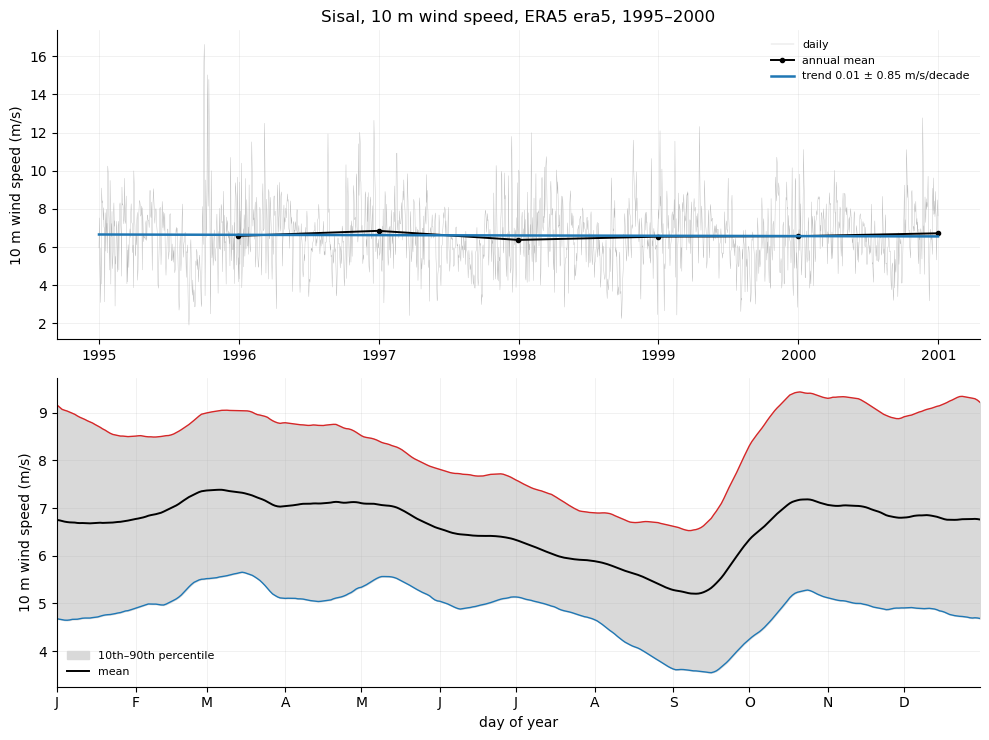

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 1, figsize=(10, 7.5))

# --- panel A: series + trend -------------------------------------------------
ax[0].plot(s.index, s.values, lw=0.25, color='0.7', label='daily')
ax[0].plot(ann.index, ann.values, lw=1.4, color='k', marker='o', ms=3,
           label='annual mean')
trend_lab = (f'trend {res.slope*10:.2f} ± {res.stderr*10*1.96:.2f} {UNIT}/decade'
             if res is not None else f'trend {slope*10:.2f} {UNIT}/decade')
ax[0].plot(s.index, slope * t_all + icpt, lw=1.8, color='tab:blue', label=trend_lab)
ax[0].set_ylabel(f"{info['label']} ({UNIT})")
ax[0].set_title(f"Sisal, {info['label']}, {info['src'].upper()} {TAG}, {YEAR0}–{YEAR1}")
ax[0].legend(frameon=False, fontsize=8, loc='best')

# --- panel B: day-of-year climatology --------------------------------------
d = clim.index.values
ax[1].fill_between(d, clim.p10, clim.p90, color='0.85', label='10th–90th percentile')
ax[1].plot(d, clim['mean'], color='k', lw=1.4, label='mean')
ax[1].plot(d, clim.p90, color='tab:red', lw=1.0)
ax[1].plot(d, clim.p10, color='tab:blue', lw=1.0)

starts = np.cumsum([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]) + 1
ax[1].set_xticks(starts)
ax[1].set_xticklabels(list('JFMAMJJASOND'))
ax[1].set_xlim(1, 365)
ax[1].set_ylabel(f"{info['label']} ({UNIT})")
ax[1].set_xlabel('day of year')
ax[1].legend(frameon=False, fontsize=8, loc='best')

for a in ax:
    a.grid(alpha=0.25, lw=0.5)
    a.spines[['top', 'right']].set_visible(False)

fig.tight_layout()
plt.show()


In [7]:
# Extreme events: runs of days above p90 ("high") or below p10 ("low").
# Only meaningful for ordinary variables; skipped for fluxes such as
# precipitation, whose daily distribution is mostly zeros.
MIN_DUR, MAX_GAP = 3, 1
HIGH, LOW = ('warm', 'cold') if info['unit'] == '°C' else ('high', 'low')

d = pd.DataFrame({'x': x.values, 'doy': doy}, index=x.index).join(clim, on='doy')

def detect(exceed, val, thresh, mean):
    """exceed: boolean series (missing days count as False). Returns event table."""
    runs, start = [], None
    for i, flag in enumerate(exceed.values):
        if flag and start is None:
            start = i
        elif not flag and start is not None:
            runs.append((start, i - 1)); start = None
    if start is not None:
        runs.append((start, len(exceed) - 1))

    joined = []                                    # merge across short gaps
    for r_ in runs:
        if joined and r_[0] - joined[-1][1] - 1 <= MAX_GAP:
            joined[-1] = (joined[-1][0], r_[1])
        else:
            joined.append(list(r_))
    joined = [r_ for r_ in joined if r_[1] - r_[0] + 1 >= MIN_DUR]

    out = []
    for a, b in joined:
        sl   = slice(a, b + 1)
        anom = val.values[sl] - thresh.values[sl]
        out.append({
            'start': exceed.index[a], 'end': exceed.index[b],
            'duration': b - a + 1,
            'i_mean': np.nanmean(np.abs(val.values[sl] - mean.values[sl])),
            'i_max':  np.nanmax(np.abs(anom)),
            'cum':    np.nansum(np.abs(anom)),
            'year':   exceed.index[a].year})
    out = pd.DataFrame(out, columns=['start', 'end', 'duration', 'i_mean',
                                     'i_max', 'cum', 'year'])
    return out.astype({'duration': 'int64', 'year': 'int64',
                       'i_mean': float, 'i_max': float, 'cum': float})

if info['kind'] == 'linear':
    high = detect(d.x > d.p90, d.x, d.p90, d['mean'])
    low  = detect(d.x < d.p10, d.x, d.p10, d['mean'])
else:
    print(f"Event detection skipped for {VAR} (kind = {info['kind']}); tables below stay empty.")
    high = low = detect(d.x > np.inf, d.x, d.p90, d['mean'])

for name, ev in [(HIGH, high), (LOW, low)]:
    msg = f'\n{name}: {len(ev)} events, {len(ev)/N_YEARS:.1f}/yr'
    if len(ev):
        msg += f', median {ev.duration.median():.0f} d, max {ev.duration.max():.0f} d'
    print(msg)
    #ev.to_csv(f'events_{name}_{VAR}_{TAG}.csv', index=False)



high: 26 events, 4.3/yr, median 4 d, max 7 d

low: 23 events, 3.8/yr, median 4 d, max 8 d


In [8]:
# share of days above p90 vs. share of days inside high events
print((d.x > d.p90).mean(), high.duration.sum() / len(d))


0.1031021897810219 0.04607664233576642


In [9]:
print(high.nlargest(10, 'duration')[['start', 'duration']])


        start  duration
8  1996-08-18         7
9  1996-11-09         7
7  1996-07-25         5
13 1997-06-19         5
20 1998-09-05         5
25 2000-10-09         5
0  1995-05-22         4
1  1995-06-15         4
3  1995-10-01         4
5  1996-02-03         4


In [10]:
# compare first and second half of the record
mid = YEAR0 + (YEAR1 - YEAR0 + 1) // 2
print(f'mean {info["label"]}: {YEAR0}-{mid-1}: {d.x[d.index.year < mid].mean():.3f}, '
      f'{mid}-{YEAR1}: {d.x[d.index.year >= mid].mean():.3f} {UNIT}')

first = high[high.year < mid].duration.sum()
last  = high[high.year >= mid].duration.sum()
print(f'{HIGH} event-days {YEAR0}-{mid-1}: {first}, {mid}-{YEAR1}: {last}')


mean 10 m wind speed: 1995-1997: 6.604, 1998-2000: 6.613 m/s
high event-days 1995-1997: 58, 1998-2000: 43


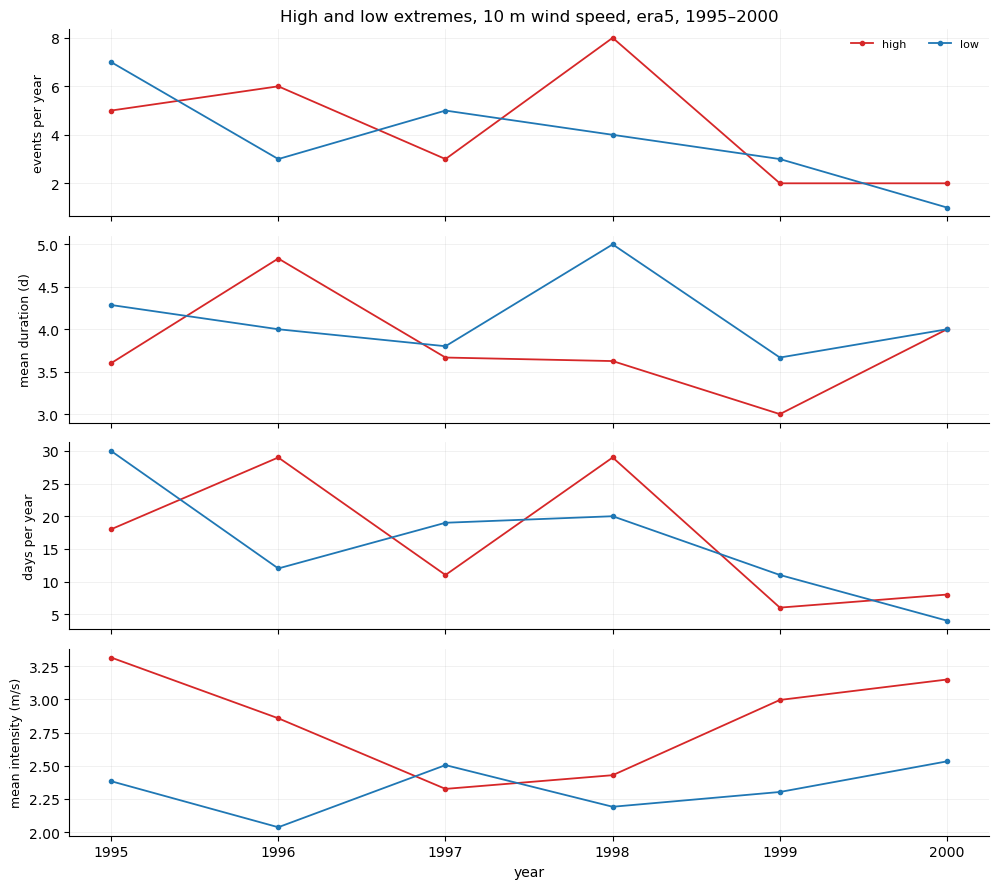

In [11]:
yrs = pd.Index(range(YEAR0, YEAR1 + 1), name='year')

def annual(ev):
    if ev.empty:
        return pd.DataFrame(0, index=yrs, columns=['count', 'duration', 'days', 'intensity'])
    g_ = ev.groupby('year')
    return pd.DataFrame({
        'count':     g_.size(),
        'duration':  g_.duration.mean(),
        'days':      g_.duration.sum(),
        'intensity': g_.i_mean.mean()}).reindex(yrs).fillna(0)

H, C = annual(high), annual(low)
rows = [('count', 'events per year'), ('duration', 'mean duration (d)'),
        ('days', 'days per year'), ('intensity', f'mean intensity ({info["unit"]})')]

fig, ax = plt.subplots(len(rows), 1, figsize=(10, 9), sharex=True)
for a, (col, lab) in zip(ax, rows):
    a.plot(yrs, H[col], color='tab:red',  lw=1.3, marker='o', ms=3, label=HIGH)
    a.plot(yrs, C[col], color='tab:blue', lw=1.3, marker='o', ms=3, label=LOW)
    a.set_ylabel(lab, fontsize=9)
    a.grid(alpha=0.25, lw=0.5)
    a.spines[['top', 'right']].set_visible(False)

ax[0].legend(frameon=False, fontsize=8, ncol=2)
ax[0].set_title(f"{HIGH.capitalize()} and {LOW} extremes, {info['label']}, {TAG}, {YEAR0}–{YEAR1}")
ax[-1].set_xlabel('year')
fig.tight_layout()
plt.show()
